#Download data

In [1]:
# to get the data
# !pip install yfinance
# !pip install lxml

In [2]:

import pandas as pd
import seaborn as sns
import numpy as np
import yfinance as yf
import requests
from io import StringIO
import math
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import keras
import torch.nn as nn
import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# get labels from wikipedia
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
html = requests.get(url, headers=headers, timeout=20)
html.raise_for_status()
sp500_df = pd.read_html(StringIO(html.text))[0]
tickers = sp500_df["Symbol"].str.replace(".", "-", regex=False).tolist() # for some reason there are 503 labels, figure out why!!!

# I think it is better to ignore the index
# tickers.insert(0,'^GSPC') # add S&P500 index, which we try to predict

# Download all S&P 500 data given the previous labels
data = yf.download(tickers=tickers,start="2015-01-01",end="2023-01-01",group_by='ticker',threads=True)

# just keep opening prices
open_prices = pd.concat({ticker: data[ticker]["Close"] for ticker in data.columns.levels[0]},axis=1)

# remove firms with nan-values, remove around 50 firms
open_prices_interp = open_prices.interpolate(method='linear', axis=0, limit=1) # if nan-values at one point then average between before and after, for instance, if uneven opening days for some reason
open_prices_interp = open_prices_interp.dropna(axis=1) # this should drop columns containing nan-values

# remove firms without sector or industry information for graphs, only removes 1 firm
tickers_with_data = list(open_prices_interp.columns)
firm_industry_dict = {}
removed_labels = []

# !!!slow as fuck, but it does the job!!!
for firm in tickers_with_data:
  info = yf.Ticker(firm).info
  try:
    firm_industry_dict[firm]= (info["sector"], info["industry"])
  except:
    print(firm)
    if not firm == '^GSPC': #of course no sector and industry information for S&P500
      removed_labels.append(firm)
      tickers_with_data.remove(firm) # missing sector or industry information about this firm, so remove it

# quick fix, i had a problem with this firm
tickers_with_data.remove('FITB')
removed_labels.append('FITB')

# remove firms without graph data
open_prices_interp = open_prices_interp.drop(columns=removed_labels)

# into numpy
x = open_prices_interp.to_numpy() #

/tmp/ipykernel_10902/3095402560.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers=tickers,start="2015-01-01",end="2023-01-01",group_by='ticker',threads=True)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
6 Failed downloads:
ERROR:yfinance:['GEV', 'SOLV', 'Q', 'SNDK', 'KVUE', 'VLTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2023-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1672549200")')


FISV


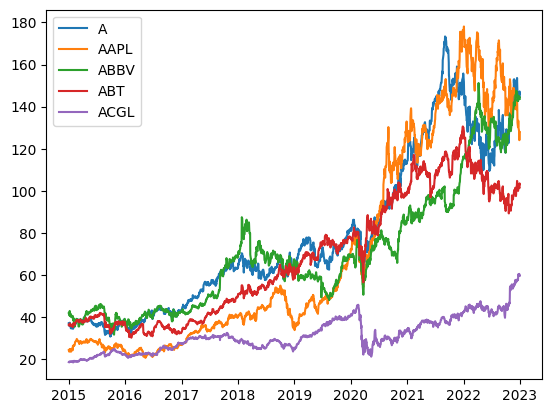

In [4]:
# just to get a visualization that it looks right
for i in open_prices_interp.columns[:5]:
  prices = open_prices_interp[i]
  plt.plot(prices.index, prices.values, label=f'{i}')
plt.legend()

In [5]:
# what do we do with those companies not on the stock exchange the entire time? Nan values, like the one below?
# I have dropped companies that contained nan values, because they were annoying. I think these companies that later joined the S&P500 and were not not a part of the stock exchange at that time
#open_prices['ABNB']

In [6]:
sum(np.isnan(x))

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

(460, 460)


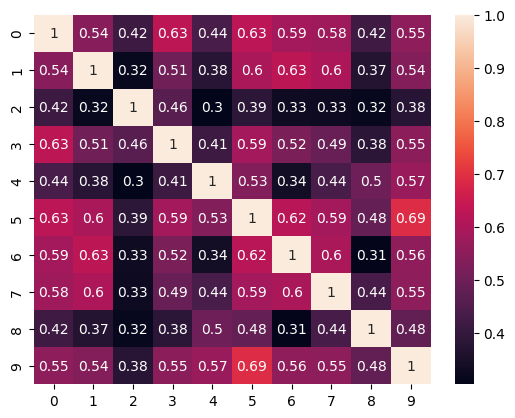

In [7]:
# Make data more stationary by using log and diff, so we get the relative changes  (I thought that an LSTM model could predict non-stationary time-series, but it was a bit tough for it)
x_returns = np.diff(np.log(x),axis=0)

# calculate the correlation
corr_ = np.corrcoef(x_returns.T)
ax = sns.heatmap(corr_[:10,:10], annot=True)
print(corr_.shape)

In [8]:
set_of_sector = set()
set_of_industry = set()
for val in firm_industry_dict.values():
  sector, industry = val
  set_of_sector.add(sector)
  set_of_industry.add(industry)

# make adjacency matrix
firm_tickers = tickers_with_data # I have removed  '^GSPC', so no difference now
N = len(firm_tickers)
A = np.zeros((N, N, 3)) # 2 types of relation, industry and sector

for i, ti in enumerate(firm_tickers):
    for j, tj in enumerate(firm_tickers):
        if ti == tj:
            continue
        if firm_industry_dict[ti][1] == firm_industry_dict[tj][1]:
            A[i, j, 0] = 1   # connection type 1
        elif firm_industry_dict[ti][0] == firm_industry_dict[tj][0]:
            A[i, j, 1] = 1   # connection type 2
# add the correlation matrix to adjacency matrix
A[:,:,2] = corr_  # this correlation is on the entire period, perhaps just do it for training period

# RQ1
## Prepare data for LSTM

In [9]:
# create moving average features, what they do in the paper
windows = [5, 10, 20, 30]

def moving_average(a, window):
    return np.apply_along_axis(lambda x: np.convolve(x, np.ones(window)/window, mode='valid'), axis=0, arr=a)

ma_dict = {w: moving_average(x_returns, w) for w in windows}
min_T = min(ma.shape[0] for ma in ma_dict.values())
x_trim = x_returns[-min_T:]
ma_trimmed = [ma_dict[w][-min_T:] for w in windows]
features = np.stack([x_trim] + ma_trimmed, axis=-1)

f'(Time point, firm, type of price)= {features.shape}'

'(Time point, firm, type of price)= (1984, 460, 5)'

## Create training, validation and test data

In [10]:
def create_data(batch_size=32, flatten_data = True, shuffle_train= True):
  # target all prices at time t
  target = features[:, :, 0]

  # split up the data
  n = len(target)
  train_end = n // 2
  val_end = train_end + n // 4
  train_raw = features[:train_end,:,:]
  val_raw   = features[train_end:val_end,:,:]
  test_raw  = features[val_end:,:, :]

  # Get original shapes for reshaping back
  train_shape = train_raw.shape
  val_shape = val_raw.shape
  test_shape = test_raw.shape

  # Reshape 3D data to 2D for StandardScaler (combine first two dimensions)
  train_reshaped = train_raw.reshape(-1, train_shape[-1])
  val_reshaped = val_raw.reshape(-1, val_shape[-1])
  test_reshaped = test_raw.reshape(-1, test_shape[-1])
  sc = StandardScaler()
  train_scaled_reshaped = sc.fit_transform(train_reshaped)
  val_scaled_reshaped   = sc.transform(val_reshaped)
  test_scaled_reshaped  = sc.transform(test_reshaped)

  # Reshape back to 3D after scaling
  train_scaled = train_scaled_reshaped.reshape(train_shape)
  val_scaled   = val_scaled_reshaped.reshape(val_shape)
  test_scaled  = test_scaled_reshaped.reshape(test_shape)

  # Concatenate along the time dimension (axis=0)
  full_scaled = np.concatenate((train_scaled, val_scaled, test_scaled), axis=0)

  seq_len = 8
  X, y = [], []
  for i in range(seq_len, len(full_scaled)):
      X.append(full_scaled[i-seq_len:i, :,:])
      y.append(full_scaled[i, :, 0])

  X = np.array(X, dtype=np.float32)
  y = np.array(y, dtype=np.float32)

  train_idx = train_end - seq_len
  val_idx   = val_end - seq_len

  X_train, y_train = X[:train_idx], y[:train_idx]
  X_val,   y_val   = X[train_idx:val_idx], y[train_idx:val_idx]
  X_test,  y_test  = X[val_idx:], y[val_idx:]

  # keras can max input 3D and not 4D
  if flatten_data:
    (T, L, N, F) = X_train.shape
    X_train = X_train.reshape(T,L,N*F)
    (T, L, N, F) = X_val.shape
    X_val = X_val.reshape(T,L,N*F)
    (T, L, N, F) = X_test.shape
    X_test = X_test.reshape(T,L,N*F)


  # Convert to torch tensors and make into mini-batches (otherwise it can crash as it uses too much RAM)
  X_train_t = torch.tensor(X_train, dtype=torch.float32)
  X_val_t   = torch.tensor(X_val, dtype=torch.float32)
  X_test_t  = torch.tensor(X_test, dtype=torch.float32)

  y_train_t = torch.tensor(y_train, dtype=torch.float32)
  y_val_t   = torch.tensor(y_val, dtype=torch.float32)
  y_test_t  = torch.tensor(y_test, dtype=torch.float32)

  print(X_train_t.shape)  # (T_train, 8, 460, 5)
  print(y_train_t.shape)  # (T_train, 460)

  train_ds = TensorDataset(X_train_t, y_train_t)
  val_ds   = TensorDataset(X_val_t, y_val_t)
  test_ds  = TensorDataset(X_test_t, y_test_t)

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train) # this includes all the data makes it into batches
  val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
  test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
  return X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader

batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(batch_size =batch_size)


torch.Size([984, 8, 2300])
torch.Size([984, 460])


## the LSTM model

In [11]:
for x,y in train_loader:
  print(x.shape, y.shape)
  break

torch.Size([32, 8, 2300]) torch.Size([32, 460])


### [new] Nat's attempt

Trying to adjust Mathias's LSTM model to put it into functions and iterate over it with different parameters

In [14]:
### Set Parameters
param_grid = {
    'lstm_units': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.5],
    # 'batch_size': [64, 128, 256],
    'learning_rate': [0.0005, 0.001],
    'patience': [10],
    'epochs': [30]
}

In [16]:
### Convert PyTorch format to be compatible with tf/keras
def dataloader_to_numpy(dataloader):
    X_list, y_list = [], []
    for X_batch, y_batch in dataloader:
        X_list.append(X_batch.numpy())
        y_list.append(y_batch.numpy())
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_train, y_train = dataloader_to_numpy(train_loader)
X_val,   y_val   = dataloader_to_numpy(val_loader)

In [17]:
### Function to build and compile the model
def build_compile_lstm_model(hidden_units, input_size, output_size, dropout_rate, learning_rate):

    model = Sequential()

    model.add(LSTM(units=hidden_units, return_sequences=True))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units=hidden_units*2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(units=output_size))
    model.build(input_shape=input_size) # This fixes "unbuilt", so we can see number of parameters in each layer. Nothing else

    # Optimizer
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    # opt = optim.Adam(model.parameters(), lr=learning_rate)

    # Metrics
    metric = ['accuracy'] # create shape ratio above? !!! , f1_score, matthews_corrcoef>

    # Compile model
    model.compile(optimizer = opt, loss = 'mean_squared_error', metrics=metric) # use mean_squared_error when regression problem

    return model

In [27]:
### Function to train the model
def train_model(model, train_data, validation_data, epochs=30, patience=10):

    X_train, y_train = train_data
    X_val,   y_val   = validation_data

    best_val_loss = 100.0
    best_weights = None
    patience_counter = 0
    history_metrics = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):

        # Training step
        history_es = model.fit(X_train, y_train, epochs=1, shuffle=False, verbose=0)

        epoch_loss = history_es.history['loss'][0]
        epoch_acc = history_es.history['accuracy'][0]

        # Validation step
        val_results = model.evaluate(X_val, y_val, verbose=0)
        val_loss = val_results[0]
        val_acc = val_results[1]

        history_metrics['train_loss'].append(epoch_loss)
        history_metrics['train_acc'].append(epoch_acc)
        history_metrics['val_loss'].append(val_loss)
        history_metrics['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

        # Patience
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.get_weights()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Restore best weights
    model.set_weights(best_weights)
    return model, history_metrics, best_val_loss

In [30]:
best_overall_loss, best_config, best_model_final, best_history_final = 100.0, {}, None, None

results_log = []
grid_search_start_time = time.time()

keys, values = zip(*param_grid.items())
# keys, values = zip(*param_grid_best.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

output_size = y_train.shape[1] # y.shape[1]
input_size = X_train.shape[:]

# configs
MODEL_SAVE_PATH = 'best_lstm_model_graphtheory.keras'

In [31]:
for i, params in enumerate(combinations):
    print(f"\n--- Training Config {i+1}/{len(combinations)}: {params} ---")

    # Build and compile the model
    model = build_compile_lstm_model(
        hidden_units=params['lstm_units'],
        input_size=input_size,
        output_size=output_size,
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    # Training time
    config_train_start_time = time.time()
    trained_model, history_metrics, val_loss = train_model(
        model, train_data=(X_train, y_train), validation_data=(X_val, y_val),
        epochs=params['epochs'], patience=params['patience'])

    config_train_end_time = time.time()
    training_duration = config_train_end_time - config_train_start_time

    # # Inference time on validation
    # inference_start_time = time.time()
    # trained_model.predict(X_val_seq, batch_size=params['batch_size'], verbose=0)
    # inference_end_time = time.time()
    # inference_duration = inference_end_time - inference_start_time

    print(f"Config {i+1} Summary: Val Loss: {val_loss:.4f} | Train Time: {training_duration:.2f}s")
    # print(f"Config {i+1} Summary: Val Loss: {val_loss:.4f} | Train Time: {training_duration:.2f}s | Inference Time: {inference_duration:.2f}s")

    results_log.append({
        'config_id': i + 1,
        'params': str(params),
        'val_loss': val_loss,
        'training_time_s': training_duration
        # 'inference_time_s': inference_duration
    })

    if val_loss < best_overall_loss:
        best_overall_loss = val_loss
        best_config = params
        best_model_final = trained_model
        best_history_final = history_metrics
        print(f"-> New Best Model found!")

grid_search_end_time = time.time()
total_duration = grid_search_end_time - grid_search_start_time

print("\n" + "="*60)
print(f"Grid Search Complete in {total_duration:.2f} seconds.")
print(f"Best Configuration: {best_config} | Best Val loss: {best_overall_loss:.4f}")
best_model_final.save(MODEL_SAVE_PATH)


print("\n--- Detailed Grid Search Results ---")
results_df = pd.DataFrame(results_log)
results_df = results_df.sort_values(by='val_loss', ascending=False)
print(results_df)


--- Training Config 1/18: {'lstm_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'patience': 10, 'epochs': 30} ---
Epoch 1/30 | Train Loss: 1.0092 Acc: 0.0030 | Val Loss: 2.6155 Val Acc: 0.0000
Epoch 2/30 | Train Loss: 0.9986 Acc: 0.0102 | Val Loss: 2.6162 Val Acc: 0.0000
Epoch 3/30 | Train Loss: 0.9842 Acc: 0.0112 | Val Loss: 2.6250 Val Acc: 0.0000
Epoch 4/30 | Train Loss: 0.9676 Acc: 0.0132 | Val Loss: 2.6383 Val Acc: 0.0020
Epoch 5/30 | Train Loss: 0.9489 Acc: 0.0234 | Val Loss: 2.6333 Val Acc: 0.0040
Epoch 6/30 | Train Loss: 0.9319 Acc: 0.0234 | Val Loss: 2.6573 Val Acc: 0.0000
Epoch 7/30 | Train Loss: 0.9132 Acc: 0.0244 | Val Loss: 2.6671 Val Acc: 0.0020
Epoch 8/30 | Train Loss: 0.8927 Acc: 0.0295 | Val Loss: 2.6861 Val Acc: 0.0020
Epoch 9/30 | Train Loss: 0.8775 Acc: 0.0274 | Val Loss: 2.7040 Val Acc: 0.0040
Epoch 10/30 | Train Loss: 0.8580 Acc: 0.0356 | Val Loss: 2.7522 Val Acc: 0.0040
Epoch 11/30 | Train Loss: 0.8482 Acc: 0.0254 | Val Loss: 2.7679 Val Acc: 0.0040
Ear

### [new] Mathias's code but with altered parameters based on above:

In [32]:
output_dim = y_train.shape[1] # y.shape[1]
# Reduce the number of units significantly as 32*output_dim is too large.
units = 64 # Changed from 32*output_dim to a fixed smaller value, they actually do not specify the units for this one
input_dim = X_train.shape[:]

model = Sequential()
model.add(LSTM(units = units, return_sequences = True))
model.add(Dropout(0.5))
model.add(LSTM(units = units*2, return_sequences = False))
model.add(Dropout(0.5))
model.add(Dense(units = output_dim))
model.build(input_shape=input_dim) # This fixes "unbuilt", so we can see number of parameters in each layer. Nothing else

es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

opt = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer = opt, loss = 'mean_squared_error')  # use mean_squared_error when regression problem
model.summary()

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_96 (LSTM)                  │ (984, 8, 64)           │       605,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (984, 8, 64)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_97 (LSTM)                  │ (984, 128)             │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (984, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (984, 460)             │        59,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,596 (2.91 MB)

 Trainable params: 763,596 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_es = model.fit(train_loader, epochs=100, validation_data=val_loader, callbacks=[es], shuffle=False) #

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.0124 - val_loss: 2.6137
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0021 - val_loss: 2.6153
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.9974 - val_loss: 2.6184
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.9869 - val_loss: 2.6235
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9786 - val_loss: 2.6317
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.9646 - val_loss: 2.6344
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9547 - val_loss: 2.6384
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9446 - val_loss: 2.6644
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9412 - val_loss: 2.6665
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9267 - val_loss: 2.6880
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9086 - val_loss: 2.6966


In [34]:
pred_scaled = model.predict(X_test[:, :, :])
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

max_left_from_ma = max(windows)//2-1
seq_len= 8
start_date_for_plot = 1 + max_left_from_ma + ( seq_len)
dates = open_prices_interp.index[start_date_for_plot : start_date_for_plot + len(y_test)]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


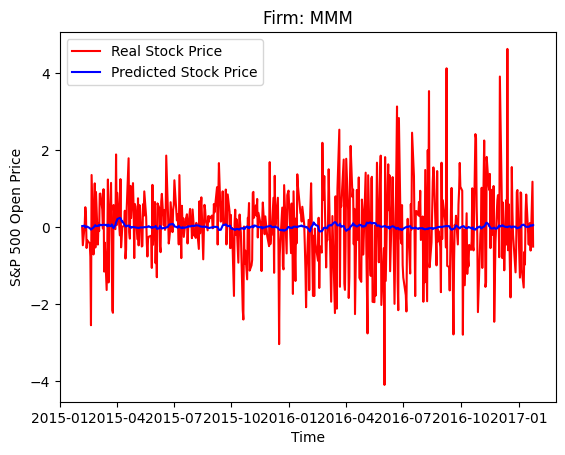

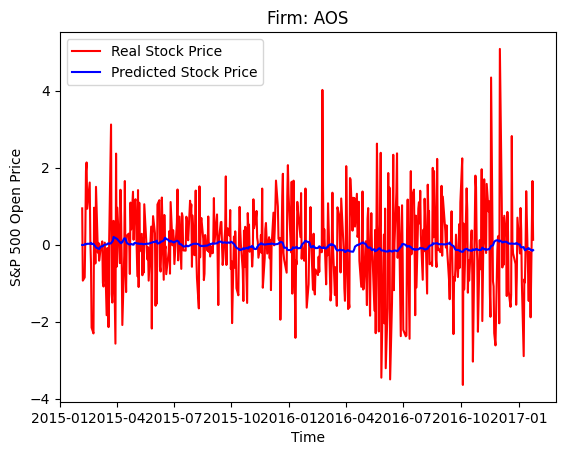

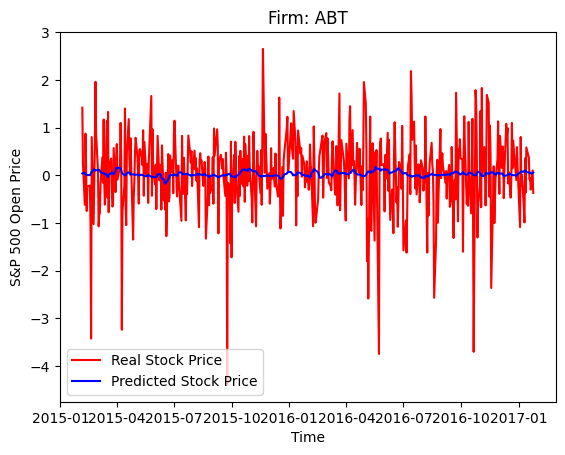

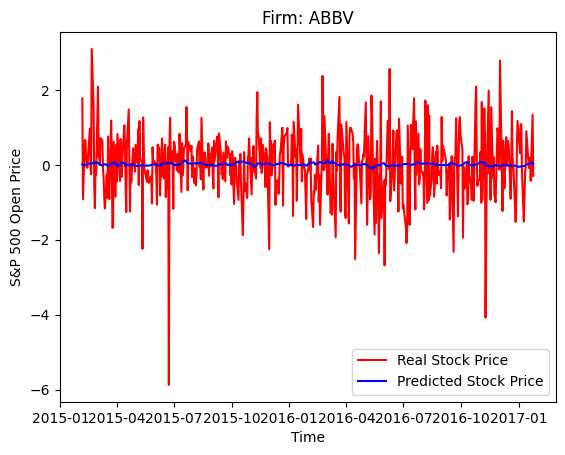

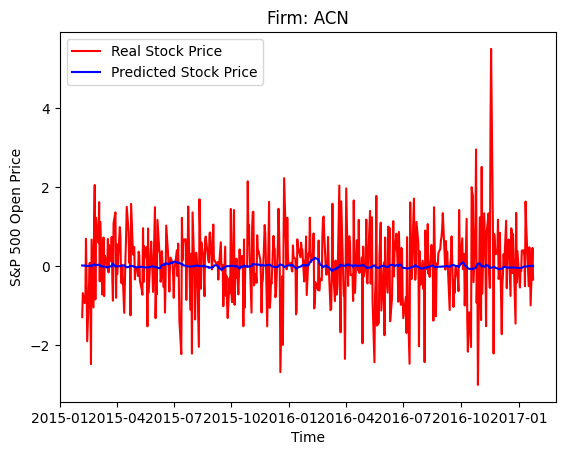

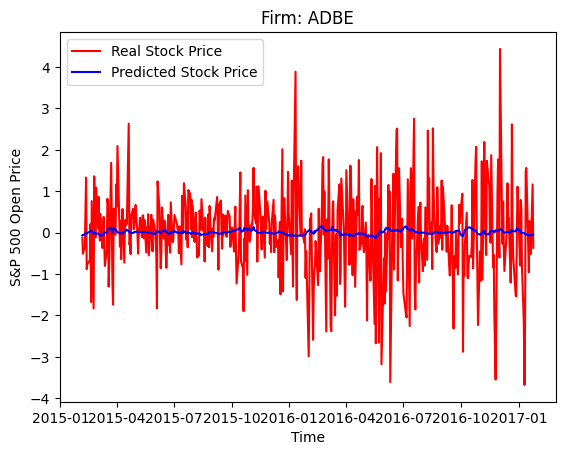

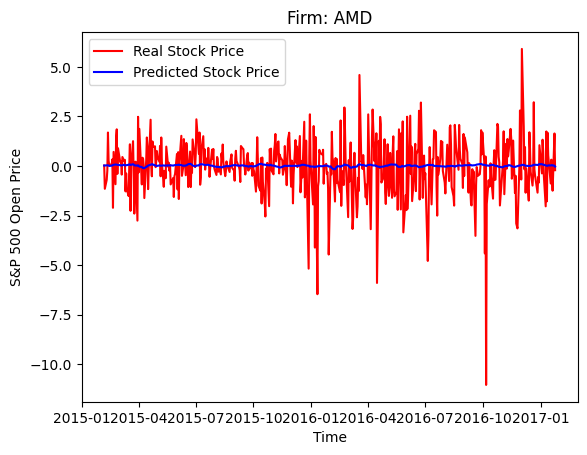

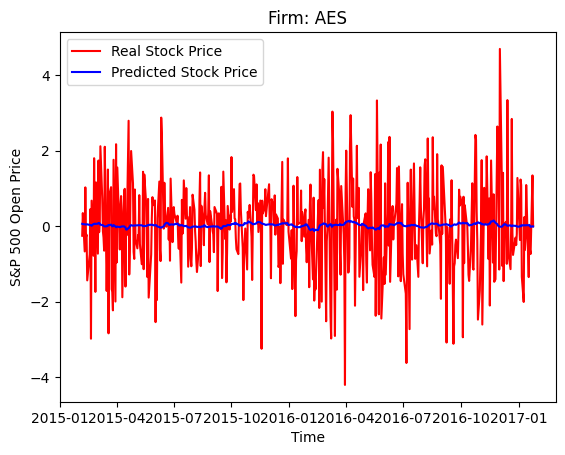

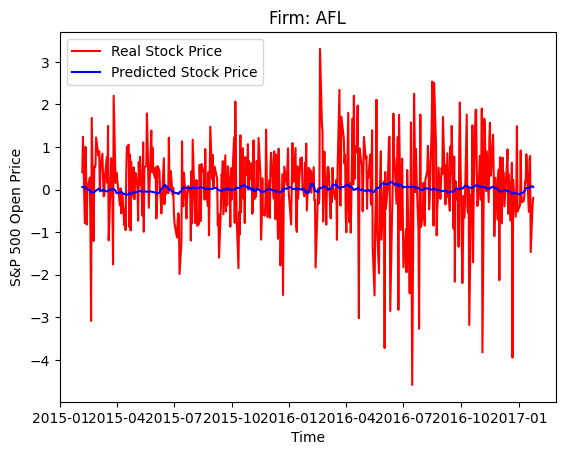

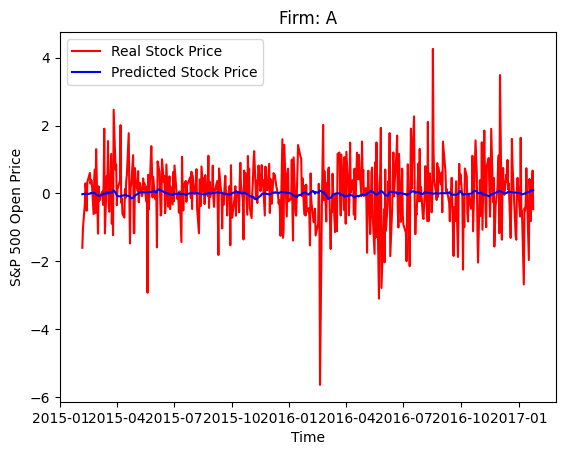

In [35]:
def plot_results(y_test, pred, nr_firms = 10):
  for i in range(nr_firms):
    plt.plot(dates, y_test[:,i], color='red', label='Real Stock Price')
    plt.plot(dates, pred_scaled[:,i], color='blue', label='Predicted Stock Price')
    plt.xlabel('Time')
    plt.ylabel('S&P 500 Open Price')
    plt.title(f"Firm: {tickers[i]}")
    plt.legend()
    plt.show()
plot_results(y_test, pred=pred_scaled) #!!! changed pred to pred_scaled

In [37]:
# It is better to just go with the average hahahh
MSE_array_average = np.mean(((y_test-np.mean(y_train, axis=0)[np.newaxis,:])**2),axis=0)
print(np.mean(MSE_array_average))
MSE_array_LSTM = np.mean((y_test-pred_scaled)**2,axis=0)
print(np.mean(MSE_array_LSTM))
sign_real = y_test>0
sign_pred = pred_scaled>0
print(f'Share for predicting right direction {np.mean((sign_real == sign_pred))}')

1.5541307
1.5564923
Share for predicting right direction 0.49894810659186534


In [47]:
print(y_test)

[[-0.01646304  0.94349295  1.4189422  ...  1.1374187   0.63627064
  -1.5447642 ]
 [-0.47123867 -0.93468463  0.23707357 ... -0.14266841 -0.08951464
  -0.38865632]
 [ 0.06435496 -0.84976023 -0.62009287 ... -0.9496572  -0.42402795
   0.20179437]
 ...
 [-0.60913616 -1.88895    -0.30128503 ... -0.63168687 -1.0227693
  -0.6305998 ]
 [ 1.1807529   1.6527067   0.1006128  ...  0.84773666  2.5196009
   1.7523459 ]
 [-0.50578773  0.1265872  -0.3724496  ... -0.17609885 -0.28238663
  -0.6719423 ]]


In [57]:
### [new] Metrics to record: accuracy, F1, MCC, Sharpe ratio
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

# Turn into binary/directional
y_test_cat = (y_test > 0).astype(int)
y_pred_scaled_cat = (pred_scaled > 0).astype(int)


# Accuracy
accuracies = [accuracy_score(y_test_cat[:, i], y_pred_scaled_cat[:, i]) for i in range(y_test_cat.shape[1])]
mean_acc = np.mean(accuracies)
print(f"Mean Accuracy: {mean_acc:.4f}")

# F1 - "Macro" F1
f1 = f1_score(y_test_cat, y_pred_scaled_cat, average='macro') # macro treats each label equally
print(f"Macro F1: {f1:.4f}")

# MCC - get per-label MCC then average it
mcc_per_label = [matthews_corrcoef(y_test_cat[:, i], y_pred_scaled_cat[:, i])
                 for i in range(y_test_cat.shape[1])]

mean_mcc = np.mean(mcc_per_label)
print(f"Mean MCC: {mean_mcc:.4f}")


# Sharpe ratio
excess_returns = pred - y_test
avg_excess_return = excess_returns.mean(axis=0)
sd_excess_return = excess_returns.std(axis=0)

daily_sharpe = avg_excess_return / (sd_excess_return + 1e-8)
annual_sharpe = daily_sharpe * np.sqrt(252)

print(f"Mean Sharpe:   {annual_sharpe.mean():.4f}")
print(f"Min Sharpe:    {annual_sharpe.min():.4f}")
print(f"Max Sharpe:    {annual_sharpe.max():.4f}")
print(f"Median Sharpe: {np.median(annual_sharpe):.4f}")


Mean Accuracy: 0.4989
Macro F1: 0.5184
Mean MCC: -0.0034
Mean Sharpe:   0.0997
Min Sharpe:    -1.2342
Max Sharpe:    1.4262
Median Sharpe: 0.1365


### Mathias's original code:

In [11]:
output_dim = y_train.shape[1] # y.shape[1]
# Reduce the number of units significantly as 32*output_dim is too large.
units = 64 # Changed from 32*output_dim to a fixed smaller value, they actually do not specify the units for this one
input_dim = X_train.shape[:]

model = Sequential()
model.add(LSTM(units = units, return_sequences = True))
model.add(Dropout(0.2))
model.add(LSTM(units = units*2, return_sequences = False))
model.add(Dropout(0.2))
model.add(Dense(units = output_dim))
model.build(input_shape=input_dim) # This fixes "unbuilt", so we can see number of parameters in each layer. Nothing else

es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)

model.compile(optimizer = 'adam', loss = 'mean_squared_error')  # use mean_squared_error when regression problem
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (984, 8, 64)           │       605,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (984, 8, 64)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (984, 128)             │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (984, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (984, 460)             │        59,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,596 (2.91 MB)

 Trainable params: 763,596 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_es = model.fit(train_loader, epochs=100, validation_data=val_loader, callbacks=[es], shuffle=False) #

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 1.0096 - val_loss: 2.6155
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.9974 - val_loss: 2.6208
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.9860 - val_loss: 2.6224
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.9733 - val_loss: 2.6314
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.9566 - val_loss: 2.6341
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.9443 - val_loss: 2.6398
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.9185 - val_loss: 2.6356
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.9020 - val_loss: 2.6886
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.8858 - val_loss: 2.7081
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.8672 - val_loss: 2.7346
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.8467 - val_loss: 2.7929


In [13]:
pred_scaled = model.predict(X_test[:, :, :])
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

max_left_from_ma = max(windows)//2-1
seq_len= 8
start_date_for_plot = 1 + max_left_from_ma + ( seq_len)
dates = open_prices_interp.index[start_date_for_plot : start_date_for_plot + len(y_test)]

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


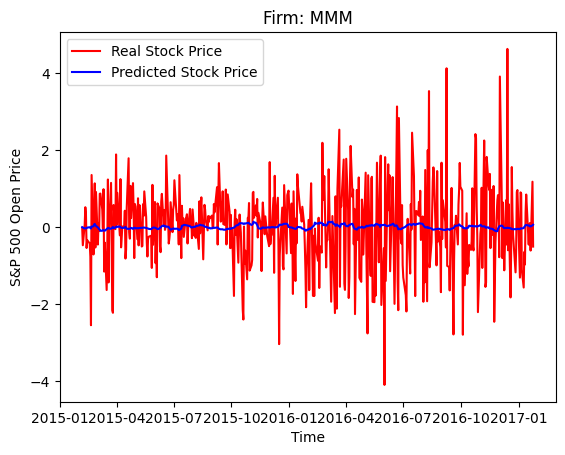

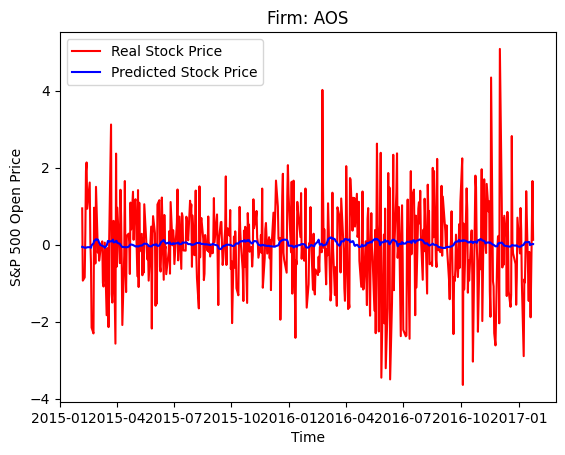

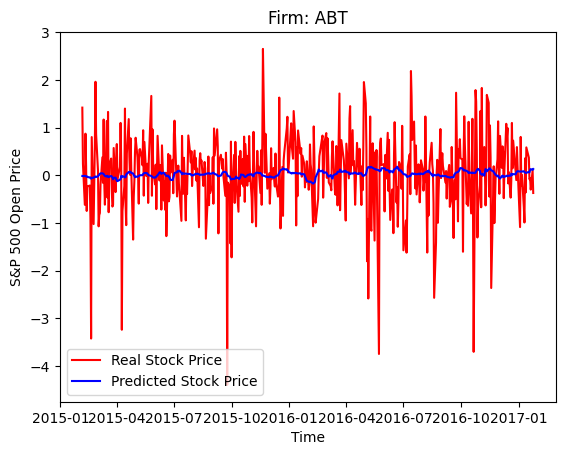

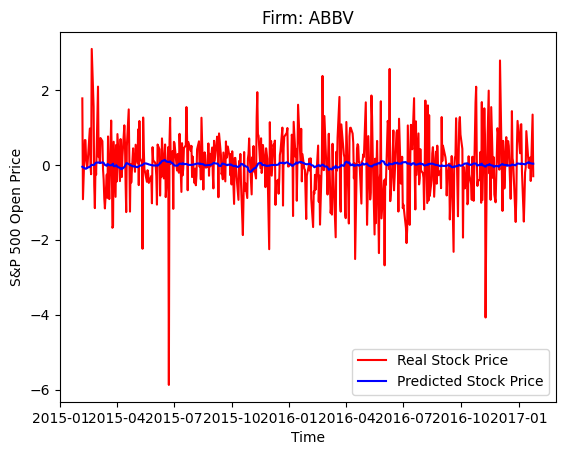

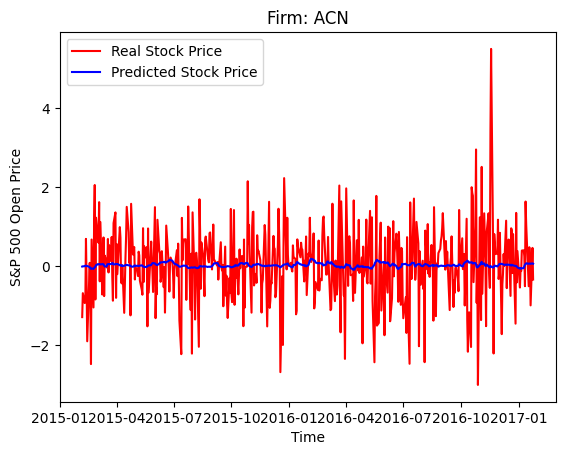

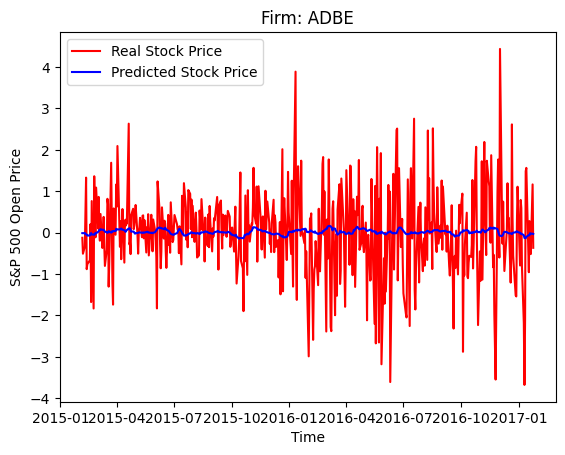

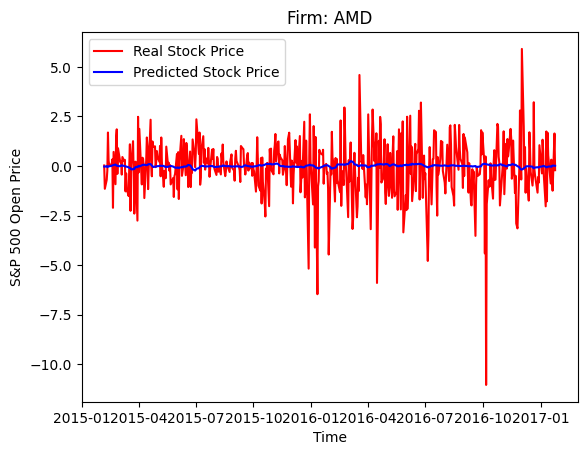

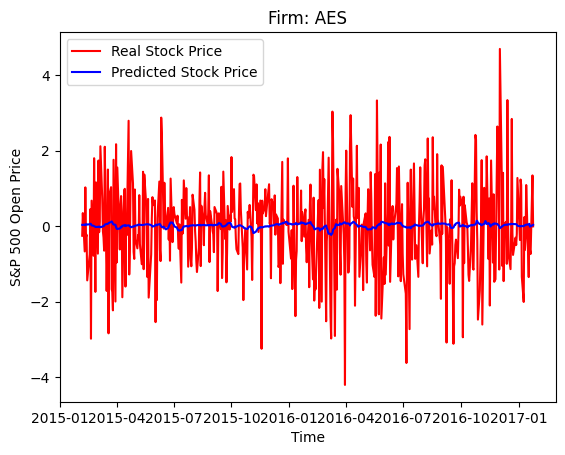

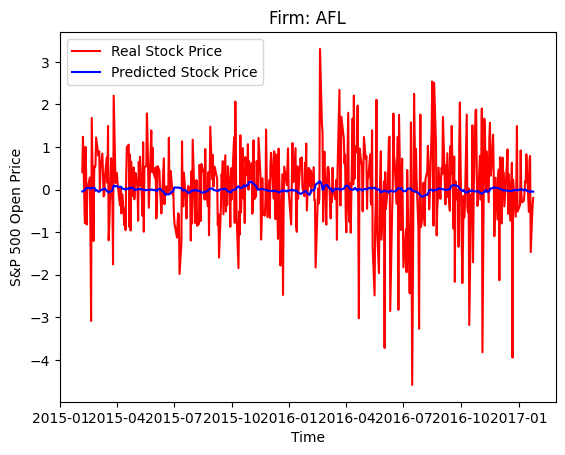

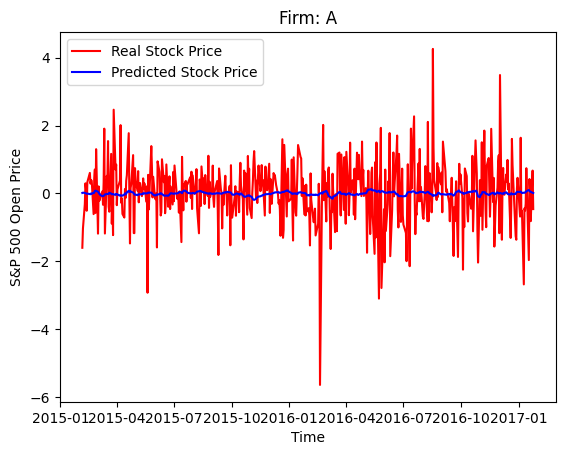

In [14]:
def plot_results(y_test, pred, nr_firms = 10):
  for i in range(nr_firms):
    plt.plot(dates, y_test[:,i], color='red', label='Real Stock Price')
    plt.plot(dates, pred_scaled[:,i], color='blue', label='Predicted Stock Price')
    plt.xlabel('Time')
    plt.ylabel('S&P 500 Open Price')
    plt.title(f"Firm: {tickers[i]}")
    plt.legend()
    plt.show()
plot_results(y_test, pred=pred_scaled) #!!! changed pred to pred_scaled

In [15]:
# It is better to just go with the average hahahh
MSE_array_average = np.mean(((y_test-np.mean(y_train, axis=0)[np.newaxis,:])**2),axis=0)
print(np.mean(MSE_array_average))
MSE_array_LSTM = np.mean((y_test-pred_scaled)**2,axis=0)
print(np.mean(MSE_array_LSTM))
sign_real = y_test>0
sign_pred = pred_scaled>0
print(f'Share for predicting right direction {np.mean((sign_real == sign_pred))}')

1.5541304
1.5566384
Share for predicting right direction 0.5012009116409537


# TGC

In [ ]:
# The TGC consists of 3 building blocks
# Block 1: The LSTM Encoder
class CompanyEncoder(nn.Module):
    def __init__(self, num_features, emb_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=emb_dim, batch_first=True)

    def forward(self, x):
        # x: [T, L, N, F]
        # Letter for dimensions: T is time periods, L length of sequences, N number of firms, F number of features, B batch size
        B, L, N, F = x.shape

        x = x.permute(0, 2, 1, 3).reshape(B * N, L, F)   # [B*N, L, F]

        _, (h_n, _) = self.lstm(x)
        E = h_n[-1].reshape(B, N, -1)                    # [B, N, emb_dim]
        return E

# Block 2: The Graph Layer
class TemporalMultiRelationGCN(nn.Module):
    def __init__(self, in_dim, out_dim, num_relations):
        super().__init__()
        self.edge_linear = nn.Linear(num_relations, 1)

    def forward(self, E, A):
        # E: [B, N, d]
        # A: [N, N, K]
        # setiup
        B, N, d = E.shape
        E_E = torch.matmul(E, E.transpose(1, 2)) # Same as e_i^T e_j in paper

        edge_score = self.edge_linear(A).squeeze(-1)
        edge_score = torch.relu(edge_score) # this is phi in the paper

        deg = edge_score.sum(dim=0, keepdim=True) + 1e-6
        edge_weight = edge_score / deg                 # phi/d

        weights = E_E * edge_weight.unsqueeze(0)       # Combine: part_1 = e_i^T e_j @ phi/d
        H = torch.matmul(weights, E)                   # combine: part_1@ e_j

        return H

# Block 3: The Dense Layer
# I think I did one extra ReLu/linear layer too much
class Header(nn.Module):
  def __init__(self, gcn_dim):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(gcn_dim, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 1)
    )

  def forward(self, x):
    return self.model(x)

class TGCModel(nn.Module):
    def __init__(self, num_features, emb_dim, gcn_dim, num_relations):
        super().__init__()
        self.encoder = CompanyEncoder(num_features, emb_dim)
        self.tgc = TemporalMultiRelationGCN(emb_dim, gcn_dim, num_relations)
        self.head = Header(gcn_dim)

    def forward(self, x, A):
        # x: [B, L, N, F]
        # A: [N, N, K]
        E = self.encoder(x)               # Embedding layer
        H = self.tgc(E, A)                # combines embeddings and adjacency matrix
        y_hat = self.head(H).squeeze(-1)  # makes N predictions
        return y_hat

In [ ]:
batch_size = 32
emb_dim = 32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(batch_size =batch_size, flatten_data=False, shuffle_train=False) # I shuffle for LSTM, perhaps bad, let's figure out
adj_matrix = torch.tensor(A, dtype=torch.float32) # this puts the adjacency matrix into the right format
K = adj_matrix.shape[-1]

torch.Size([984, 8, 460, 5])
torch.Size([984, 460])


In [ ]:
# if you guys want to test the things yourself inside TGCModel
# step 0. get a batch and their dimensions
x0, y0 = next(iter(train_loader))
B, L, N, F = x0.shape
# step 1. initialise the encoder and get the embedding matrix, E
encode_model = CompanyEncoder(num_features =F, emb_dim=emb_dim)
E = encode_model(x0) # this does the embedding layer
# step 3. setup the GNN part where we use graph information
gcn_model = TemporalMultiRelationGCN(in_dim=emb_dim, out_dim=emb_dim, num_relations=K)
H_k = gcn_model(E, adj_matrix) #
# step 4. save linear predicter and do the prediction
head = Header(emb_dim)
yhat = head(H_k).squeeze(-1) # shape [B,N]

## Train TGC model

In [ ]:
# functions for training, evaluating and predicting
def train_one_epoch(model, loader, A, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()

        pred = model(x_batch, A)        # [B, N]
        loss = criterion(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def evaluate(model, loader, A, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        pred = model(x_batch, A)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def predict(model, loader, A):
    model.eval()
    preds = []
    ys = []

    for x_batch, y_batch in loader:
        pred = model(x_batch, A)

        preds.append(pred.cpu())
        ys.append(y_batch)

    preds = torch.cat(preds, dim=0)
    return preds

### do the training


In [ ]:
# do the training
num_epochs = 20
adj_matrix = torch.tensor(A, dtype=torch.float32)
dict_adj_matrices = {'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                     'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                     'corre':     {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,2].unsqueeze(-1), 'pred':np.empty},
                     'everything':{'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,:],               'pred':np.empty} }

for key in dict_adj_matrices.keys():
  print(f'Doing model: {key}')
  A_loop = dict_adj_matrices[key]['matrix']
  K_num_relations = A_loop.shape[-1] # This will be 1 for single relations, and 3 for 'everything'

  model_TGC = TGCModel(num_features=F, emb_dim=emb_dim, gcn_dim=emb_dim, num_relations=K_num_relations)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model_TGC.parameters(), lr=1e-3)

  for epoch in range(num_epochs):
      train_loss = train_one_epoch(model_TGC, train_loader, A_loop, optimizer, criterion)
      val_loss = evaluate(model_TGC, val_loader, A_loop, criterion)

      print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
  dict_adj_matrices[key]['model'] = model_TGC

  pred_test_TGC = predict(model_TGC, test_loader, A_loop)
  dict_adj_matrices[key]['pred'] = pred_test_TGC

  dict_adj_matrices[key]['MSE'] = np.mean((y_test-pred_test_TGC.numpy())**2,axis=0)

Doing model: sector
Epoch 01 | train_loss=1.006375 | val_loss=2.621741
Epoch 02 | train_loss=1.002799 | val_loss=2.620480
Epoch 03 | train_loss=1.002449 | val_loss=2.628071
Epoch 04 | train_loss=1.001812 | val_loss=2.636256
Epoch 05 | train_loss=1.001618 | val_loss=2.654483
Epoch 06 | train_loss=1.001030 | val_loss=2.680708
Epoch 07 | train_loss=1.000478 | val_loss=2.710410
Epoch 08 | train_loss=1.000080 | val_loss=2.738011
Epoch 09 | train_loss=0.999666 | val_loss=2.775643
Epoch 10 | train_loss=0.999187 | val_loss=2.842703
Epoch 11 | train_loss=0.998535 | val_loss=2.879078
Epoch 12 | train_loss=0.998015 | val_loss=2.965360
Epoch 13 | train_loss=0.997168 | val_loss=2.981444
Epoch 14 | train_loss=0.996766 | val_loss=3.056770
Epoch 15 | train_loss=0.995840 | val_loss=3.051177
Epoch 16 | train_loss=0.994873 | val_loss=3.308515
Epoch 17 | train_loss=0.995817 | val_loss=2.841466
Epoch 18 | train_loss=0.996865 | val_loss=3.358175
Epoch 19 | train_loss=0.997128 | val_loss=2.991749
Epoch 20 | 

In [ ]:
MSE_dict = {'MSE_array_average': MSE_array_average, 'MSE_array_LSTM': MSE_array_LSTM}
for key in dict_adj_matrices.keys():
  MSE_dict[f'MSE_array_{key}'] = dict_adj_matrices[key]['MSE']

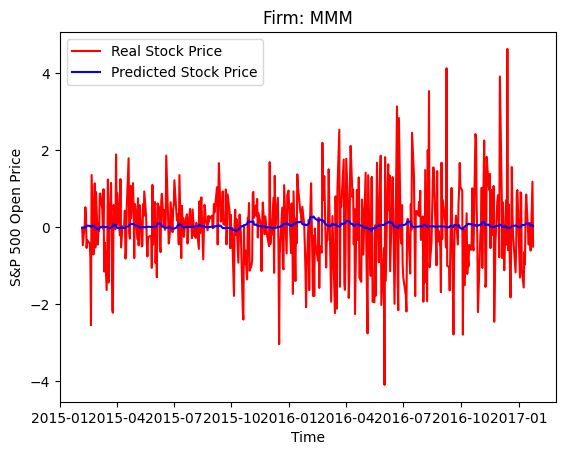

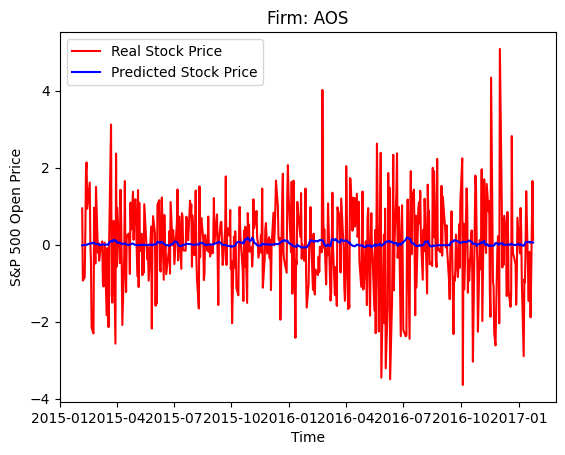

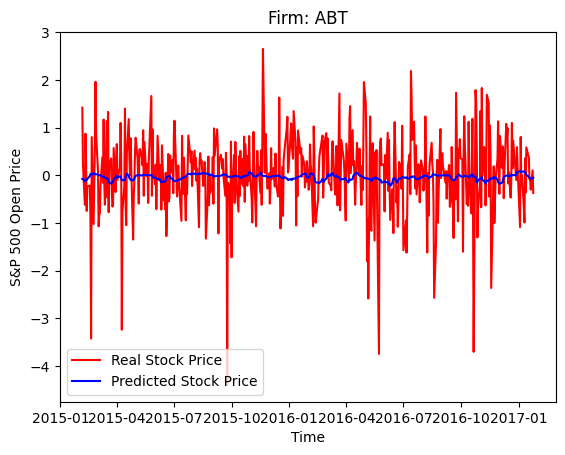

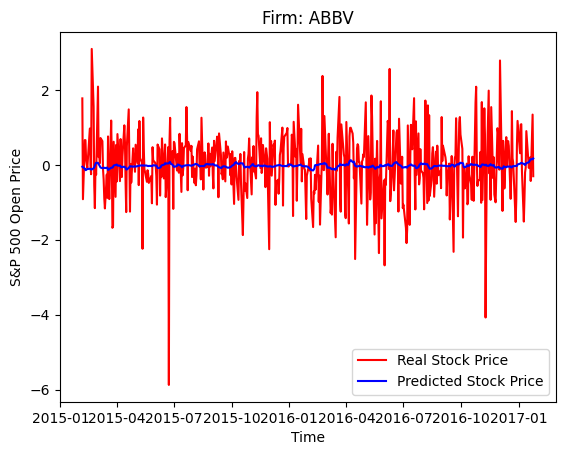

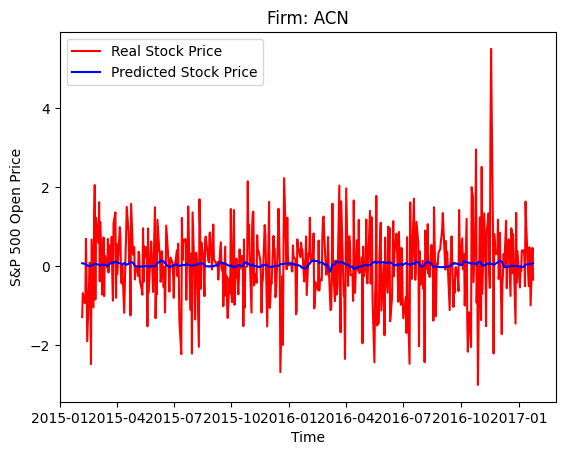

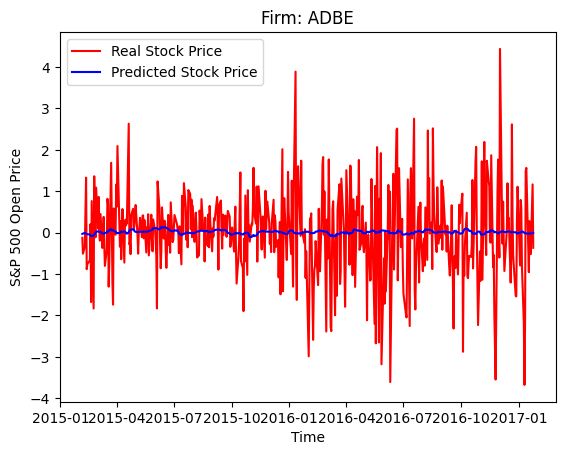

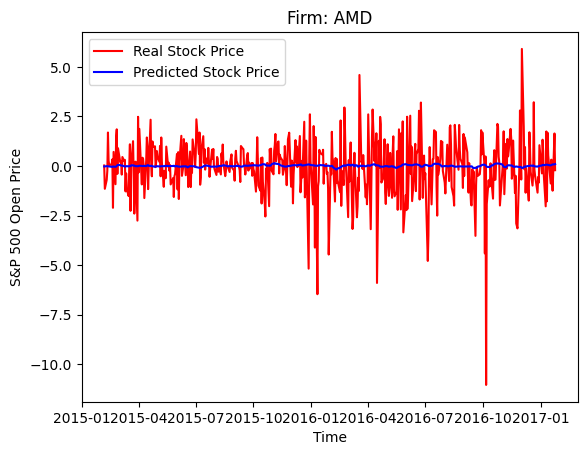

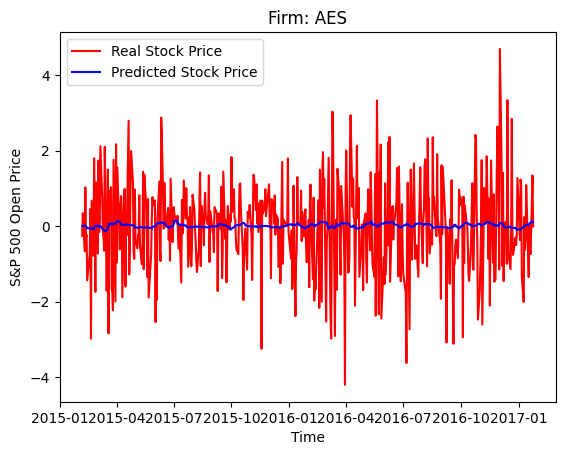

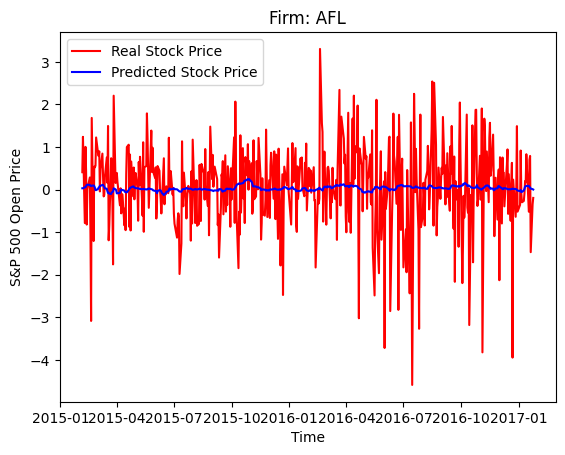

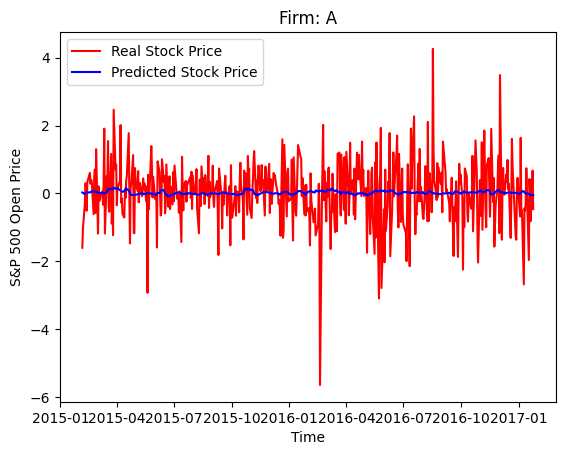

In [ ]:
pred_test_TGC = dict_adj_matrices['everything']['pred']
plot_results(y_test, pred_test_TGC)

In [ ]:
for key, val in MSE_dict.items():
  print(f'{key}: {np.mean(val)}')

MSE_array_average: 1.5541304349899292
MSE_array_LSTM: 1.5559345483779907
MSE_array_sector: 1.5814268589019775
MSE_array_industry: 1.6049138307571411
MSE_array_corre: 1.580917477607727
MSE_array_everything: 1.5604140758514404


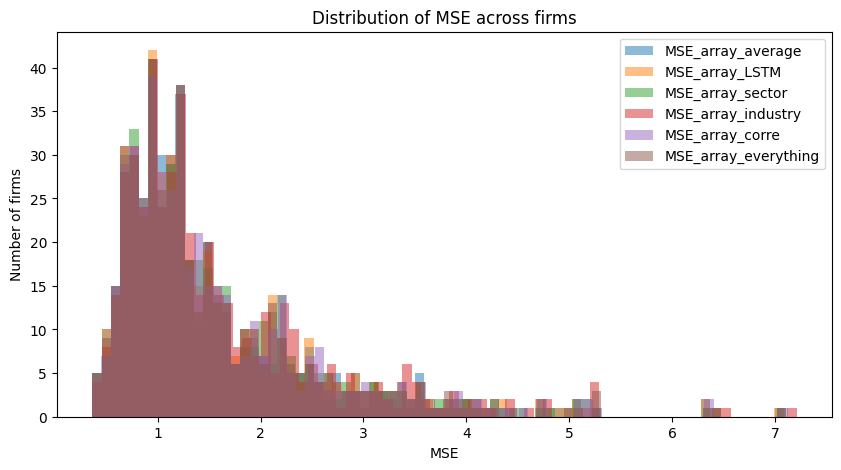

In [ ]:
# plot results that compares average, LSTM, and TGC
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for key, val in MSE_dict.items():
  plt.hist(val, bins=75, alpha=0.5, label=f'{key}')

plt.legend()
plt.title("Distribution of MSE across firms")
plt.xlabel("MSE")
plt.ylabel("Number of firms")
plt.show()

/tmp/ipykernel_3800/3062524137.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(val_list, labels=label_list)


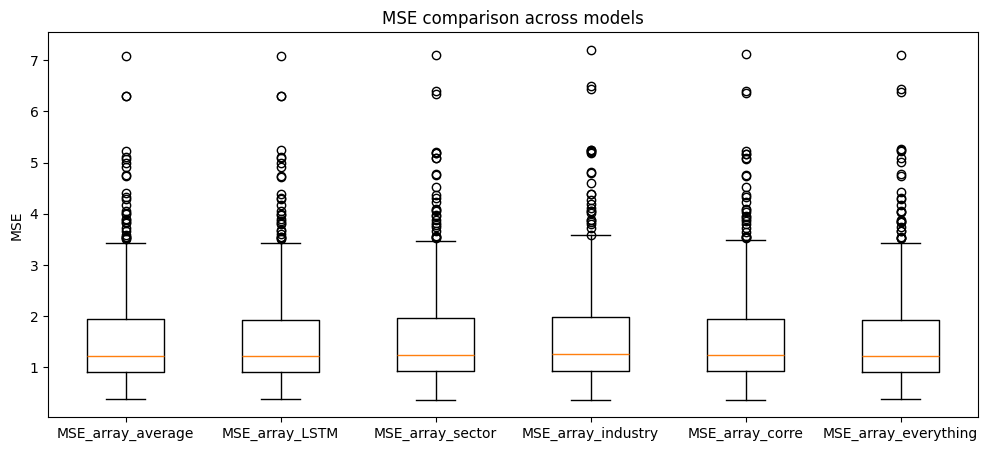

In [ ]:
plt.figure(figsize=(12,5))

val_list = []
label_list = []
for key, val in MSE_dict.items():
  val_list.append(val)
  label_list.append(key)

plt.boxplot(val_list, labels=label_list)

plt.title("MSE comparison across models")
plt.ylabel("MSE")
plt.show()